In [19]:
import seaborn as sns
import pandas as pd
import json
from pathlib import Path
from matplotlib.patches import Ellipse
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1 import make_axes_locatable
from matplotlib.colors import ListedColormap

In [20]:
result_path = Path("../results/downstream_task")
bias_type = "less_positive_class"
less_bias_strength = "0.1"
method = "fw-mrs-temperature-comparison"
data_set_name = "folktables_income"

In [21]:
dropped_samples_file_name = result_path / data_set_name / bias_type / less_bias_strength / method / "validation" / "dropped_samples_individual_val_dict.json"
with open(dropped_samples_file_name) as file:
        dropped_samples = json.load(file)
        dropped_samples = pd.DataFrame(dropped_samples)
auroc_file_name = result_path / data_set_name / bias_type / less_bias_strength / method / "validation" / "auroc_individual_val_dict.json"
with open(auroc_file_name) as file:
        aurocs = json.load(file)
        aurocs = pd.DataFrame(aurocs)

In [22]:
aurocs

,0.001,0.0025,0.005,0.01,0.025,0.05,0.1,0.25,0.5,0.0
0,0.729427,0.748993,0.770150,0.783523,0.810630,0.823270,0.831408,0.833556,0.833599,0.837557
1,0.712387,0.747247,0.784943,0.801381,0.827981,0.834247,0.836545,0.837376,0.840739,0.839480
2,0.695302,0.664277,0.761333,0.771423,0.799444,0.816620,0.824983,0.824690,0.825141,0.826371
3,0.713374,0.748050,0.773375,0.790499,0.815384,0.831506,0.832934,0.838036,0.836932,0.840056
4,0.707838,0.731648,0.766872,0.788096,0.818286,0.826252,0.825138,0.836159,0.836580,0.836715
5,0.701309,0.761768,0.800028,0.812799,0.841306,0.856028,0.858074,0.851821,0.855110,0.855894
6,0.716304,0.751371,0.785823,0.795158,0.825054,0.834785,0.842941,0.846336,0.844567,0.842877
7,0.714221,0.758972,0.788353,0.793900,0.810666,0.802473,0.829155,0.830815,0.830315,0.836533
8,0.712116,0.754055,0.769199,0.783194,0.814815,0.834650,0.838209,0.843095,0.843540,0.844670
9,0.704017,0.723842,0.770200,0.790691,0.828726,0.834280,0.849565,0.853436,0.848581,0.850995


In [23]:
temperature_labels = {}
temperature_labels[0.0] = "MRS"
temperature_labels[0.5] = "0.5000" 
temperature_labels[0.25] = "0.2500"
temperature_labels[0.1] = "0.1000"
temperature_labels[0.05] = "0.0050"
temperature_labels[0.025] = "0.0250"
temperature_labels[0.01] = "0.0100"
temperature_labels[0.005] = "0.0050"
temperature_labels[0.0025] = "0.0025"
temperature_labels[0.001] = "0.0010"

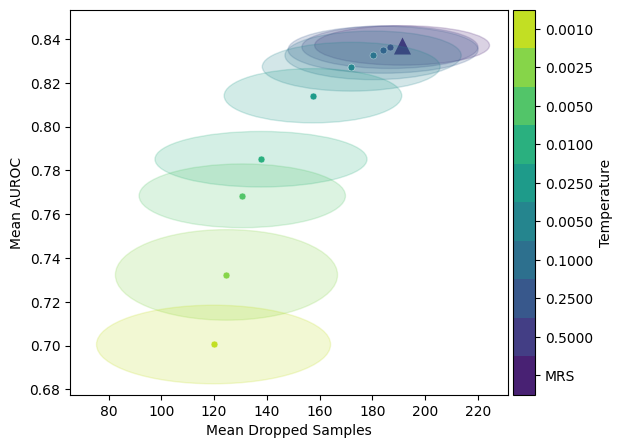

In [25]:
palette = sns.color_palette("viridis", n_colors=len(temperature_labels))
cmap = ListedColormap(palette)
fig = plt.figure(figsize=(6,5))
mrs_value = 0.0
min_x = np.inf
min_y = np.inf

for i, key in enumerate(temperature_labels.keys()):
    dropped_value = dropped_samples[str(key)]
    auroc_value = aurocs[str(key)]
    if float(key) == mrs_value:
        marker= "^"
        size= 200
    else: 
        marker = "o"
        size= 25
        
    color = cmap(i)
    ax = sns.scatterplot(x=[dropped_value.mean()], y=[auroc_value.mean()], label=key, alpha=1, color=color, marker=marker,
                         s=size,)
    ellipse = Ellipse((dropped_value.mean(), auroc_value.mean()),
                       width=2*dropped_value.std(), height=2*auroc_value.std(), alpha=0.2,
                       color=color)
    min_x = min(min_x, dropped_value.mean() - dropped_value.std())
    min_y = min(min_y, auroc_value.mean() - auroc_value.std())
    ax.add_patch(ellipse)

plt.gca().legend_.remove()

divider = make_axes_locatable(plt.gca())
ax_cb = divider.new_horizontal(size="5%", pad=0.05)
fig.add_axes(ax_cb)
cbar = matplotlib.colorbar.ColorbarBase(ax_cb, cmap=cmap,
                                orientation='vertical')
cbar.set_label('Temperature')
cbar.set_ticks(np.linspace(0.05,0.95,10))
cbar.set_ticklabels(temperature_labels.values())
ax.set_xlim(min_x - 10)
ax.set_ylim(min_y - 0.005)

_= ax.set(xlabel="Mean Dropped Samples", ylabel="Mean AUROC")
plt.savefig("diagrams/temperature_comparison_fixed.pdf", bbox_inches="tight", pad_inches=0.0)